# CHƯƠNG 1. KHÁM PHÁ DỮ LIỆU (EDA) — BIKE SHARING DATASET

## Giới thiệu và Bối cảnh

Hệ thống chia sẻ xe đạp (Bike Sharing System) cho phép người dùng thuê xe tại một trạm và trả tại một trạm bất kỳ trong mạng lưới. Nhu cầu thuê biến động phức tạp theo giờ trong ngày, loại ngày (ngày làm việc hay ngày nghỉ), mùa trong năm và các điều kiện thời tiết thực tế. 

Notebook này thực hiện toàn diện quy trình **Khám phá dữ liệu (Exploratory Data Analysis – EDA)** trên bộ dữ liệu **Bike Sharing Dataset** từ UCI Machine Learning Repository (Fanaee-T & Gama, 2013), phản ánh lịch sử vận hành thực tế của hệ thống **Capital Bikeshare** tại Washington D.C. trong hai năm 2011–2012.

### Mục tiêu chính của Chương 1:
1. **Mô tả cấu trúc và bản chất biến số:** Xác định kiểu dữ liệu, thang đo, đơn vị và vai trò nghiệp vụ.
2. **Kiểm tra chất lượng dữ liệu và tiền xử lý:** Rà soát giá trị thiếu, trùng lặp, bất thường vật lý (`hum = 0`, `windspeed = 0`) và tính liên tục của chuỗi thời gian (165 giờ thiếu); thực hiện kiểm tra độ nhạy (sensitivity analysis).
3. **Phân tích phân phối và hành vi nhu cầu:** Đánh giá độ lệch, độ nhọn, mức độ over-dispersion của biến mục tiêu `cnt` và so sánh các phép biến đổi dữ liệu.
4. **Phát hiện và phân loại giá trị ngoại lai:** Đánh giá ngưỡng toàn cục và cục bộ theo (`hr`, `workingday`); phân tích tự tương quan chuỗi thời gian (ACF) và định lượng cỡ mẫu hiệu dụng ($N_{\text{eff}}$).


In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import statsmodels.tsa.stattools as smt

# Cấu hình hiển thị biểu đồ chuẩn học thuật và hỗ trợ tiếng Việt có dấu
plt.rcParams['font.sans-serif'] = ['DejaVu Sans', 'Arial', 'Segoe UI']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams.update({
    "figure.dpi": 120,
    "axes.titleweight": "bold",
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.fontsize": 9
})
sns.set_theme(style="whitegrid", palette="deep")
BLUE, RED, GREY, ORANGE = "#3b6ea5", "#d1495b", "#8d99ae", "#e08e45"

DATA_PATH = '../data/hour.csv'
ASSETS_DIR = 'assets'
os.makedirs(ASSETS_DIR, exist_ok=True)
os.makedirs('cleaned_data', exist_ok=True)

df_raw = pd.read_csv(DATA_PATH)
df = df_raw.copy()
print(f"Đọc dữ liệu thành công: {df.shape[0]:,} dòng × {df.shape[1]} biến.")


Đọc dữ liệu thành công: 17,379 dòng × 17 biến.


## 1.1. Tổng quan cấu trúc dữ liệu và Từ điển biến

Biến mục tiêu chính là **`cnt`** (tổng số lượt thuê xe/giờ), gồm hai thành phần: `casual` (khách vãng lai) và `registered` (thành viên đăng ký), với ràng buộc $cnt = casual + registered$.

> **Quy tắc chống rò rỉ dữ liệu (Data Leakage):** Tuyệt đối không dùng `casual` và `registered` làm biến giải thích độc lập khi dự báo `cnt`.

Các biến thời tiết `temp`, `atemp`, `hum`, `windspeed` đã được tác giả gốc chuẩn hóa về thang $[0, 1]$. Toàn bộ phân tích giữ nguyên thang đo chuẩn hóa này và quy đổi khi diễn giải thực tiễn.


In [10]:
data_dict = pd.DataFrame([
    ("instant",    "Chỉ số định danh bản ghi (1 đến 17,379)",              "Identifier"),
    ("dteday",     "Ngày quan sát (YYYY-MM-DD)",                         "Date/Time"),
    ("season",     "Mùa (1: Xuân, 2: Hè, 3: Thu, 4: Đông)",               "Categorical (Định danh)"),
    ("yr",         "Năm (0: 2011, 1: 2012)",                             "Categorical (Nhị phân)"),
    ("mnth",       "Tháng trong năm (1 đến 12)",                          "Categorical (Chu kỳ)"),
    ("hr",         "Khung giờ trong ngày (0 đến 23)",                     "Categorical (Chu kỳ)"),
    ("holiday",    "Ngày lễ (1: Ngày lễ, 0: Ngày thường)",                "Categorical (Nhị phân)"),
    ("weekday",    "Thứ trong tuần (0: Chủ nhật đến 6: Thứ bảy)",         "Categorical (Chu kỳ)"),
    ("workingday", "Ngày làm việc (1: Ngày làm việc, 0: Ngày nghỉ/lễ)",  "Categorical (Nhị phân)"),
    ("weathersit", "Thời tiết (1: Quang, 2: Mây, 3: Mưa nhỏ, 4: Bão)",    "Categorical (Thứ bậc)"),
    ("temp",       "Nhiệt độ thực tế chuẩn hóa (thang -8 đến +39 °C)",    "Numerical (Liên tục)"),
    ("atemp",      "Nhiệt độ cảm nhận chuẩn hóa (thang -16 đến +50 °C)",  "Numerical (Liên tục)"),
    ("hum",        "Độ ẩm không khí chuẩn hóa (chia 100)",                "Numerical (Liên tục)"),
    ("windspeed",  "Tốc độ gió chuẩn hóa (chia 67 dặm/giờ)",              "Numerical (Mức rời rạc)"),
    ("casual",     "Số lượt thuê của khách vãng lai (lượt/giờ)",          "Numerical (Biến đếm)"),
    ("registered", "Số lượt thuê của thành viên đăng ký (lượt/giờ)",      "Numerical (Biến đếm)"),
    ("cnt",        "Tổng số lượt thuê xe trong giờ (BIẾN MỤC TIÊU)",      "Numerical (Biến đếm)"),
], columns=["Tên biến", "Ý nghĩa nghiệp vụ", "Phân loại"])

data_dict["Kiểu dữ liệu"] = data_dict["Tên biến"].map(df.dtypes.astype(str))
data_dict["Số giá trị duy nhất"] = data_dict["Tên biến"].map(df.nunique())
data_dict


,Tên biến,Ý nghĩa nghiệp vụ,Phân loại,Kiểu dữ liệu,Số giá trị duy nhất
0,instant,"Chỉ số định danh bản ghi (1 đến 17,379)",Identifier,int64,17379
1,dteday,Ngày quan sát (YYYY-MM-DD),Date/Time,str,731
2,season,"Mùa (1: Xuân, 2: Hè, 3: Thu, 4: Đông)",Categorical (Định danh),int64,4
3,yr,"Năm (0: 2011, 1: 2012)",Categorical (Nhị phân),int64,2
4,mnth,Tháng trong năm (1 đến 12),Categorical (Chu kỳ),int64,12
5,hr,Khung giờ trong ngày (0 đến 23),Categorical (Chu kỳ),int64,24
6,holiday,"Ngày lễ (1: Ngày lễ, 0: Ngày thường)",Categorical (Nhị phân),int64,2
7,weekday,Thứ trong tuần (0: Chủ nhật đến 6: Thứ bảy),Categorical (Chu kỳ),int64,7
8,workingday,"Ngày làm việc (1: Ngày làm việc, 0: Ngày nghỉ/lễ)",Categorical (Nhị phân),int64,2
9,weathersit,"Thời tiết (1: Quang, 2: Mây, 3: Mưa nhỏ, 4: Bão)",Categorical (Thứ bậc),int64,4


## 1.2. Kiểm tra chất lượng dữ liệu và Tiền xử lý

Quy trình rà soát bao gồm 4 nhóm:
1. **Toàn vẹn cấu trúc:** Kiểm tra ô trống (Missing) và dòng trùng lặp (Duplicates).
2. **Ràng buộc logic:** Kiểm tra đẳng thức $cnt = casual + registered$, logic lịch `workingday` vs (`weekday`, `holiday`).
3. **Bất thường vật lý & đo đạc:** Rà soát 22 dòng `hum = 0` (2011-03-10) và 2,180 dòng `windspeed = 0`.
4. **Chuỗi thời gian:** Khảo sát 165 giờ bị thiếu trong 2 năm.


In [11]:
# 1. Kiểm tra thiếu và trùng
missing_count = df.isna().sum().sum()
dup_rows = df.duplicated().sum()
dup_keys = df.duplicated(subset=["dteday", "hr"]).sum()

# 2. Kiểm tra ràng buộc logic
dt_check = pd.to_datetime(df["dteday"])
logic_cnt = (df["cnt"] != df["casual"] + df["registered"]).sum()
logic_weekday = (((dt_check.dt.dayofweek + 1) % 7) != df["weekday"]).sum()
logic_workingday = (df["workingday"] != (df["weekday"].between(1, 5) & (df["holiday"] == 0)).astype(int)).sum()

print("--- KẾT QUẢ KIỂM TRA CHẤT LƯỢNG BAN ĐẦU ---")
print(f"1. Tổng số ô trống (Missing)             : {missing_count}")
print(f"2. Số dòng trùng lặp hoàn toàn           : {dup_rows}")
print(f"3. Số cặp (dteday, hr) bị trùng          : {dup_keys}")
print(f"4. Số dòng vi phạm cnt = casual + reg    : {logic_cnt}")
print(f"5. Số dòng weekday không khớp dteday     : {logic_weekday}")
print(f"6. Số dòng workingday mâu thuẫn          : {logic_workingday}")
print(f"7. Số dòng hum == 0                      : {(df['hum'] == 0).sum()} (ngày {df.loc[df['hum'] == 0, 'dteday'].unique()})")
print(f"8. Số dòng windspeed == 0                : {(df['windspeed'] == 0).sum()} ({(df['windspeed'] == 0).mean()*100:.2f}%)")
print(f"9. Tương quan Pearson temp - atemp       : {df['temp'].corr(df['atemp']):.4f}")
print(f"10. Số dòng weathersit == 4 (Bão lớn)    : {(df['weathersit'] == 4).sum()}")


--- KẾT QUẢ KIỂM TRA CHẤT LƯỢNG BAN ĐẦU ---
1. Tổng số ô trống (Missing)             : 0
2. Số dòng trùng lặp hoàn toàn           : 0
3. Số cặp (dteday, hr) bị trùng          : 0
4. Số dòng vi phạm cnt = casual + reg    : 0
5. Số dòng weekday không khớp dteday     : 0
6. Số dòng workingday mâu thuẫn          : 0
7. Số dòng hum == 0                      : 22 (ngày <StringArray>
['2011-03-10']
Length: 1, dtype: str)
8. Số dòng windspeed == 0                : 2180 (12.54%)
9. Tương quan Pearson temp - atemp       : 0.9877
10. Số dòng weathersit == 4 (Bão lớn)    : 3


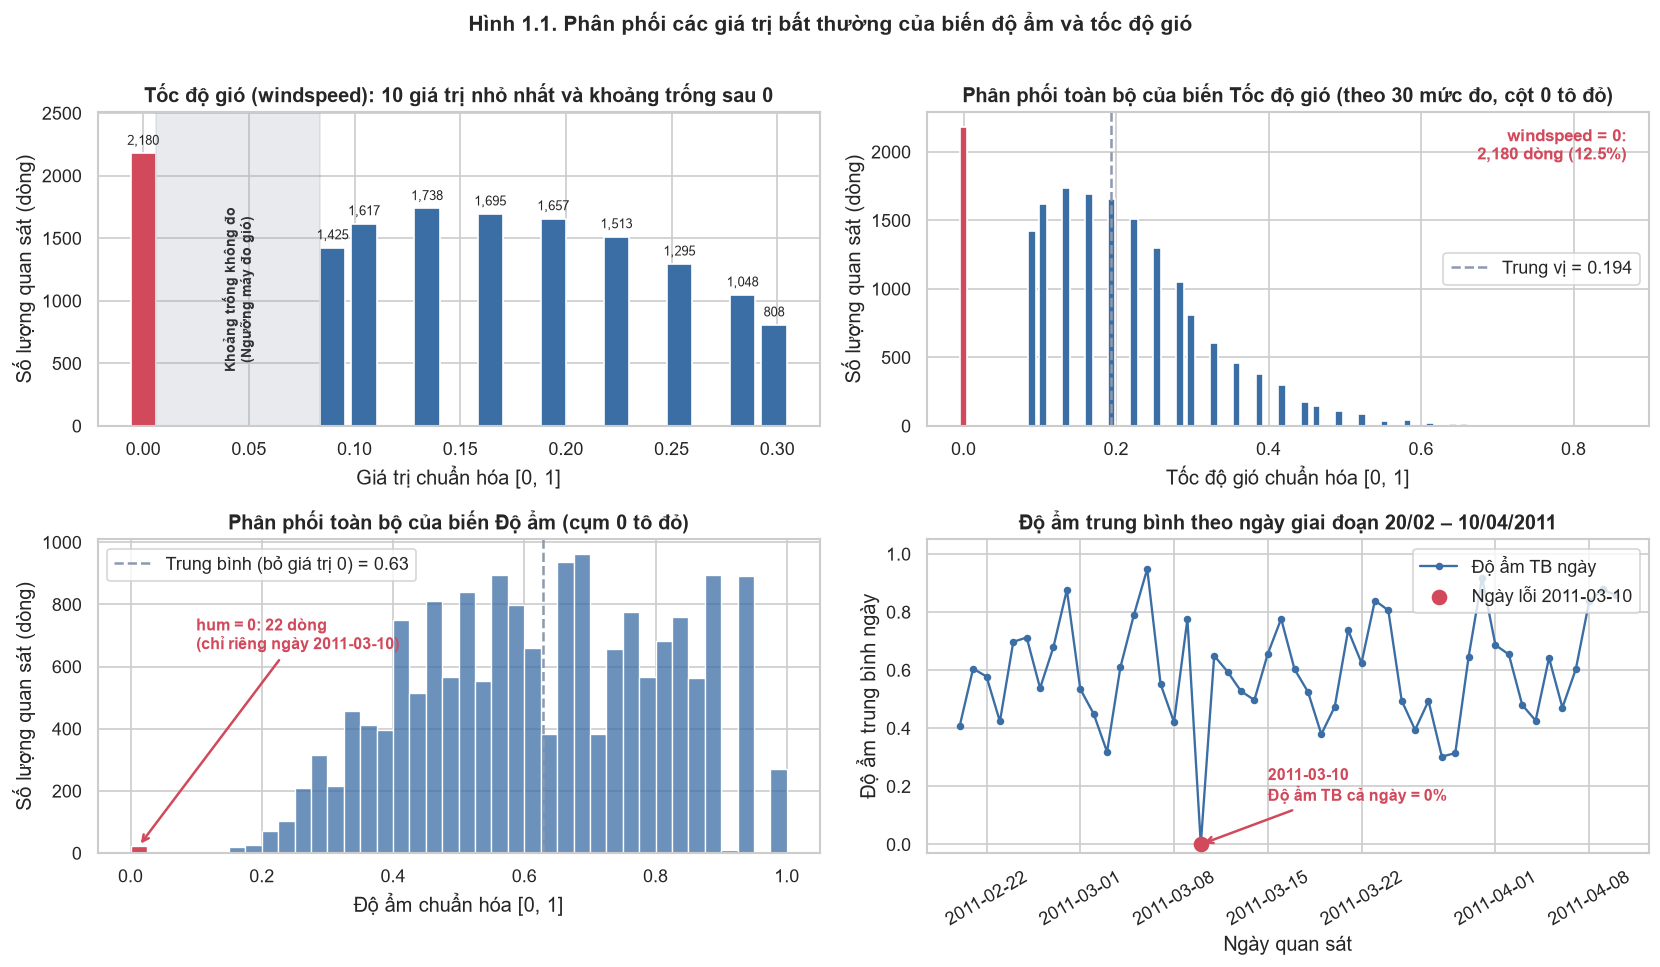

In [12]:
# Hình 1.1. Các giá trị bất thường của biến độ ẩm và tốc độ gió
n_ws0 = (df["windspeed"] == 0).sum()
n_hum0 = (df["hum"] == 0).sum()
ws_min_pos = df.loc[df["windspeed"] > 0, "windspeed"].min()

fig, ax = plt.subplots(2, 2, figsize=(14, 8))

# (1) 10 giá trị nhỏ nhất của windspeed
vc_ws = df["windspeed"].value_counts().sort_index().head(10)
ax[0, 0].bar(vc_ws.index, vc_ws.values, width=0.012, color=[RED] + [BLUE] * (len(vc_ws) - 1))
ax[0, 0].axvspan(0.006, ws_min_pos - 0.006, color=GREY, alpha=0.2)
ax[0, 0].text((0.006 + ws_min_pos - 0.006) / 2, vc_ws.values.max() * 0.5, "Khoảng trống không đo\n(Ngưỡng máy đo gió)", 
              rotation=90, ha="center", va="center", color="#333333", fontsize=8.5, fontweight="bold")
for x, v in zip(vc_ws.index, vc_ws.values):
    ax[0, 0].text(x, v + vc_ws.values.max() * 0.02, f"{v:,}", ha="center", va="bottom", fontsize=8)
ax[0, 0].set_ylim(0, vc_ws.values.max() * 1.15)
ax[0, 0].set_title("Tốc độ gió (windspeed): 10 giá trị nhỏ nhất và khoảng trống sau 0")
ax[0, 0].set_xlabel("Giá trị chuẩn hóa [0, 1]")
ax[0, 0].set_ylabel("Số lượng quan sát (dòng)")

# (2) Phân phối toàn bộ windspeed
vc_all_ws = df["windspeed"].value_counts().sort_index()
ax[0, 1].bar(vc_all_ws.index, vc_all_ws.values, width=0.010, color=[RED] + [BLUE] * (len(vc_all_ws) - 1))
ax[0, 1].text(0.97, 0.95, f"windspeed = 0:\n{n_ws0:,} dòng ({n_ws0 / len(df):.1%})", 
              transform=ax[0, 1].transAxes, ha="right", va="top", color=RED, fontsize=10, fontweight="bold")
ax[0, 1].axvline(df["windspeed"].median(), color=GREY, ls="--", lw=1.5, label=f"Trung vị = {df['windspeed'].median():.3f}")
ax[0, 1].legend(loc="center right")
ax[0, 1].set_title("Phân phối toàn bộ của biến Tốc độ gió (theo 30 mức đo, cột 0 tô đỏ)")
ax[0, 1].set_xlabel("Tốc độ gió chuẩn hóa [0, 1]")
ax[0, 1].set_ylabel("Số lượng quan sát (dòng)")

# (3) Phân phối toàn bộ hum
sns.histplot(df["hum"], bins=np.linspace(0, 1, 41), color=BLUE, ax=ax[1, 0])
ax[1, 0].patches[0].set_facecolor(RED)
ax[1, 0].annotate(f"hum = 0: {n_hum0} dòng\n(chỉ riêng ngày 2011-03-10)", xy=(0.0125, n_hum0), 
                  xytext=(0.10, ax[1, 0].get_ylim()[1] * 0.65),
                  color=RED, fontsize=9.5, fontweight="bold", arrowprops=dict(arrowstyle="->", color=RED, lw=1.5))
ax[1, 0].axvline(df.loc[df["hum"] > 0, "hum"].mean(), color=GREY, ls="--", lw=1.5, label=f"Trung bình (bỏ giá trị 0) = {df.loc[df['hum'] > 0, 'hum'].mean():.2f}")
ax[1, 0].legend(loc="upper left")
ax[1, 0].set_title("Phân phối toàn bộ của biến Độ ẩm (cụm 0 tô đỏ)")
ax[1, 0].set_xlabel("Độ ẩm chuẩn hóa [0, 1]")
ax[1, 0].set_ylabel("Số lượng quan sát (dòng)")

# (4) Độ ẩm trung bình theo ngày quanh đợt bất thường
daily_hum = df.assign(d=dt_check).groupby("d")["hum"].mean()
win_hum = daily_hum["2011-02-20":"2011-04-10"]
ax[1, 1].plot(win_hum.index, win_hum.values, marker="o", ms=3.5, lw=1.4, color=BLUE, label="Độ ẩm TB ngày")
bad_hum = win_hum[win_hum == 0]
ax[1, 1].scatter(bad_hum.index, bad_hum.values, color=RED, s=70, zorder=4, label="Ngày lỗi 2011-03-10")
ax[1, 1].annotate("2011-03-10\nĐộ ẩm TB cả ngày = 0%", xy=(bad_hum.index[0], 0), 
                  xytext=(bad_hum.index[0] + pd.Timedelta(days=5), 0.15),
                  color=RED, fontsize=9.5, fontweight="bold", arrowprops=dict(arrowstyle="->", color=RED, lw=1.5))
ax[1, 1].set_title("Độ ẩm trung bình theo ngày giai đoạn 20/02 – 10/04/2011")
ax[1, 1].set_xlabel("Ngày quan sát")
ax[1, 1].set_ylabel("Độ ẩm trung bình ngày")
ax[1, 1].set_ylim(-0.03, 1.05)
ax[1, 1].tick_params(axis="x", rotation=30)
ax[1, 1].legend(loc="upper right")

plt.suptitle("Hình 1.1. Phân phối các giá trị bất thường của biến độ ẩm và tốc độ gió", fontsize=12.5, fontweight="bold", y=1.005)
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/hinh1.1.png", dpi=300, bbox_inches="tight")
plt.show()


Tổng số giờ kỳ vọng: 17,544 | Thực tế ghi nhận: 17,379 | Thiếu: 165 (0.94%)
Số giờ thiếu ở khung rạng sáng 2–5h: 98 / 165 (59.39%)


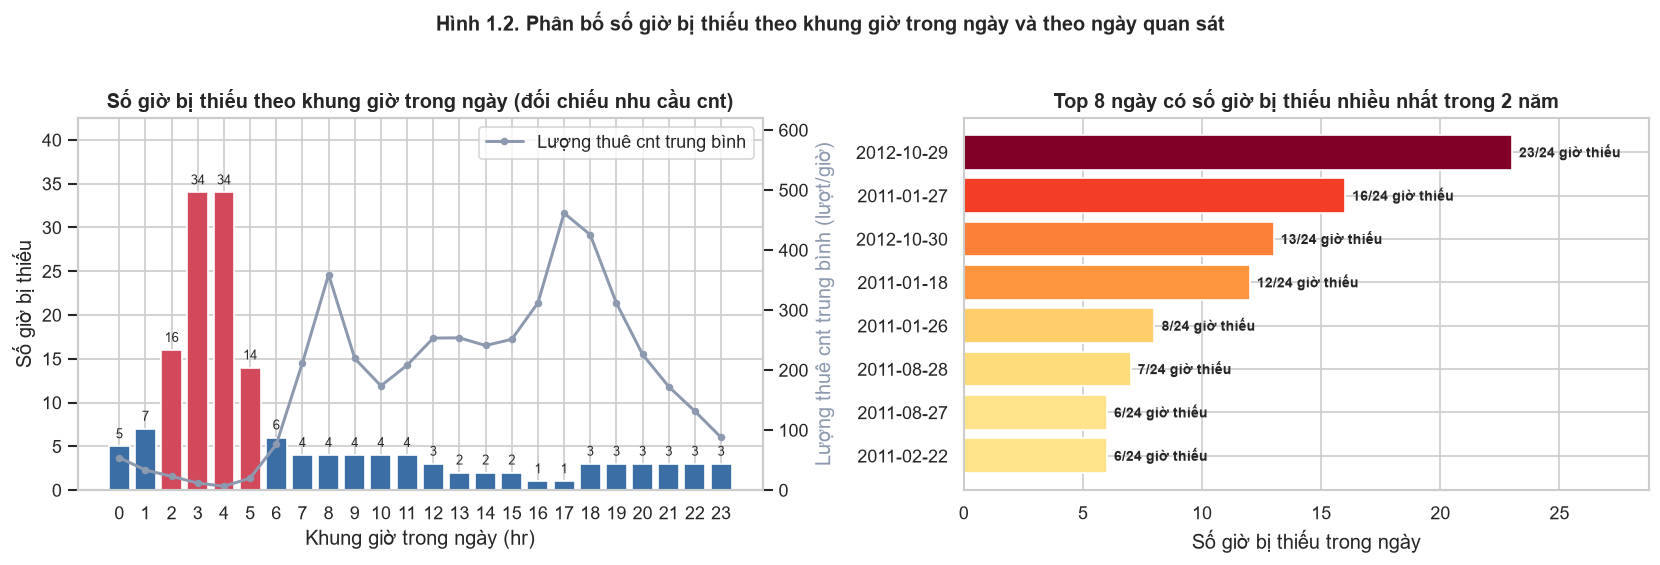

In [13]:
# Phân tích chuỗi thời gian và 165 giờ thiếu
df["_ts"] = pd.to_datetime(df["dteday"]) + pd.to_timedelta(df["hr"], unit="h")
full_timeline = pd.date_range("2011-01-01 00:00", "2012-12-31 23:00", freq="h")
missing_ts = full_timeline.difference(df["_ts"])

miss_by_hr = pd.Series(missing_ts.hour).value_counts().reindex(range(24), fill_value=0)
miss_by_day = pd.Series(missing_ts.normalize()).value_counts()
n_night = miss_by_hr.loc[2:5].sum()

print(f"Tổng số giờ kỳ vọng: {len(full_timeline):,} | Thực tế ghi nhận: {len(df):,} | Thiếu: {len(missing_ts)} ({len(missing_ts)/len(full_timeline):.2%})")
print(f"Số giờ thiếu ở khung rạng sáng 2–5h: {n_night} / {len(missing_ts)} ({n_night / len(missing_ts):.2%})")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.6))

# (1) Số giờ thiếu theo khung giờ đối chiếu nhu cầu cnt
ax[0].bar(miss_by_hr.index, miss_by_hr.values, color=[RED if 2 <= h <= 5 else BLUE for h in miss_by_hr.index], edgecolor="white")
for h, v in miss_by_hr.items():
    if v > 0:
        ax[0].text(h, v + 0.6, str(v), ha="center", va="bottom", fontsize=8)
ax2 = ax[0].twinx()
ax2.plot(range(24), df.groupby("hr")["cnt"].mean().values, color=GREY, marker="o", ms=3.5, lw=1.8, label="Lượng thuê cnt trung bình")
ax2.set_ylabel("Lượng thuê cnt trung bình (lượt/giờ)", color=GREY)
ax2.grid(False)
ax2.set_ylim(0, 620)
ax2.legend(loc="upper right")
ax[0].set_xticks(range(24))
ax[0].set_ylim(0, miss_by_hr.max() * 1.25)
ax[0].set_title("Số giờ bị thiếu theo khung giờ trong ngày (đối chiếu nhu cầu cnt)")
ax[0].set_xlabel("Khung giờ trong ngày (hr)")
ax[0].set_ylabel("Số giờ bị thiếu")

# (2) Top 8 ngày thiếu nhiều giờ nhất
top_missing_days = miss_by_day.nlargest(8).sort_values()
cmap = plt.get_cmap("YlOrRd")
norm = plt.Normalize(vmin=top_missing_days.min() - 4, vmax=top_missing_days.max())
bar_colors = [cmap(norm(v)) for v in top_missing_days.values]

ax[1].barh([d.strftime("%Y-%m-%d") for d in top_missing_days.index], top_missing_days.values, color=bar_colors, edgecolor="white")
for i, v in enumerate(top_missing_days.values):
    ax[1].text(v + 0.3, i, f"{v}/24 giờ thiếu", va="center", fontsize=8.5, fontweight="bold")
ax[1].set_xlim(0, top_missing_days.max() * 1.25)
ax[1].set_title("Top 8 ngày có số giờ bị thiếu nhiều nhất trong 2 năm")
ax[1].set_xlabel("Số giờ bị thiếu trong ngày")

plt.suptitle("Hình 1.2. Phân bố số giờ bị thiếu theo khung giờ trong ngày và theo ngày quan sát", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/hinh1.2.png", dpi=300, bbox_inches="tight")
plt.show()
df.drop(columns="_ts", inplace=True)


In [14]:
# KIỂM TRA ĐỘ NHẠY (SENSITIVITY ANALYSIS)
cnt_orig = df["cnt"]
cnt_fill_night = pd.concat([cnt_orig, pd.Series([0] * 98)])
cnt_fill_all = pd.concat([cnt_orig, pd.Series([0] * 165)])

sens_df = pd.DataFrame({
    "Kịch bản": ["Dữ liệu hiện tại (17,379 dòng)", "Điền 98 giờ đêm (2-5h) = 0", "Điền toàn bộ 165 giờ thiếu = 0"],
    "Mean cnt": [cnt_orig.mean(), cnt_fill_night.mean(), cnt_fill_all.mean()],
    "Median cnt": [cnt_orig.median(), cnt_fill_night.median(), cnt_fill_all.median()],
    "Std cnt": [cnt_orig.std(), cnt_fill_night.std(), cnt_fill_all.std()],
    "Độ lệch (%) so với gốc": [0.0, (cnt_fill_night.mean() - cnt_orig.mean()) / cnt_orig.mean() * 100, (cnt_fill_all.mean() - cnt_orig.mean()) / cnt_orig.mean() * 100]
}).round(2)
display(sens_df)

# TIỀN XỬ LÝ CHÍNH THỨC
# 1. Chuyển đổi dteday sang datetime
df["dteday"] = pd.to_datetime(df["dteday"])

# 2. Xử lý 22 dòng hum = 0 bằng nội suy cùng giờ ngày liền trước và liền sau
bad_mask = df["hum"] == 0
bad_day = df.loc[bad_mask, "dteday"].iloc[0]
prev_day = df.loc[df.dteday == bad_day - pd.Timedelta(days=1)].set_index("hr")["hum"]
next_day = df.loc[df.dteday == bad_day + pd.Timedelta(days=1)].set_index("hr")["hum"]
ref_by_hr = pd.concat([prev_day, next_day], axis=1).mean(axis=1)
df.loc[bad_mask, "hum"] = df.loc[bad_mask, "hr"].map(ref_by_hr)

# Lưu tập dữ liệu đã làm sạch
df.to_csv('cleaned_data/hour_cleaned.csv', index=False)
print("Xuất tệp cleaned_data/hour_cleaned.csv thành công!")


,Kịch bản,Mean cnt,Median cnt,Std cnt,Độ lệch (%) so với gốc
0,"Dữ liệu hiện tại (17,379 dòng)",189.46,142.0,181.39,0.00
1,Điền 98 giờ đêm (2-5h) = 0,188.40,141.0,181.43,-0.56
2,Điền toàn bộ 165 giờ thiếu = 0,187.68,140.0,181.46,-0.94


Xuất tệp cleaned_data/hour_cleaned.csv thành công!


## 1.3. Thống kê mô tả các biến số lượng và phân nhóm

Bảng 1.4 trình bày các chỉ số thống kê mô tả mở rộng gồm Mean, Median, Std, Min, Q1, Q3, Max, IQR, Skewness và Kurtosis của toàn bộ các biến số lượng.


In [15]:
def describe_extended(frame, cols):
    d = frame[cols].describe(percentiles=[.25, .5, .75]).T
    out = pd.DataFrame({
        "Count": d["count"].astype(int),
        "Mean": d["mean"].round(2),
        "Median": d["50%"].round(2),
        "Std": d["std"].round(2),
        "Min": d["min"].round(2),
        "Q1": d["25%"].round(2),
        "Q3": d["75%"].round(2),
        "Max": d["max"].round(2),
        "IQR": (d["75%"] - d["25%"]).round(2),
        "Skewness": frame[cols].skew().round(2),
        "Kurtosis": frame[cols].kurtosis().round(2)
    })
    return out

stats_cols = ["cnt", "registered", "casual", "temp", "atemp", "hum", "windspeed"]
table_1_4 = describe_extended(df, stats_cols)
display(table_1_4)


,Count,Mean,Median,Std,Min,Q1,Q3,Max,IQR,Skewness,Kurtosis
cnt,17379,189.46,142.00,181.39,1.00,40.00,281.00,977.00,241.00,1.28,1.42
registered,17379,153.79,115.00,151.36,0.00,34.00,220.00,886.00,186.00,1.56,2.75
casual,17379,35.68,17.00,49.31,0.00,4.00,48.00,367.00,44.00,2.50,7.57
temp,17379,0.50,0.50,0.19,0.02,0.34,0.66,1.00,0.32,-0.01,-0.94
atemp,17379,0.48,0.48,0.17,0.00,0.33,0.62,1.00,0.29,-0.09,-0.85
hum,17379,0.63,0.63,0.19,0.08,0.48,0.78,1.00,0.30,-0.08,-0.91
windspeed,17379,0.19,0.19,0.12,0.00,0.10,0.25,0.85,0.15,0.57,0.59


In [16]:
# Bảng 1.5. Thống kê cnt theo Mùa, Thời tiết, Loại ngày và Năm
season_map = {1: "1: Mùa xuân (Spring)", 2: "2: Mùa hè (Summer)", 3: "3: Mùa thu (Fall)", 4: "4: Mùa đông (Winter)"}
weather_map = {1: "1: Trời quang (Clear)", 2: "2: Mây / Sương mù (Mist/Cloudy)", 3: "3: Mưa / Tuyết nhẹ (Light Rain/Snow)", 4: "4: Bão / Mưa tuyết lớn (Heavy Rain/Snow)"}
workingday_map = {0: "0: Ngày nghỉ / Cuối tuần / Lễ", 1: "1: Ngày làm việc (Working Day)"}
yr_map = {0: "2011", 1: "2012"}
weekday_map = {0: "Chủ nhật", 1: "Thứ Hai", 2: "Thứ Ba", 3: "Thứ Tư", 4: "Thứ Năm", 5: "Thứ Sáu", 6: "Thứ Bảy"}

df_eda = df.assign(
    season_label=df["season"].map(season_map),
    weather_label=df["weathersit"].map(weather_map),
    workingday_label=df["workingday"].map(workingday_map),
    yr_label=df["yr"].map(yr_map),
    weekday_label=df["weekday"].map(weekday_map)
)

def get_group_stats(df_in, col):
    g = df_in.groupby(col)["cnt"].agg(
        Số_bản_ghi="count",
        Mean="mean",
        Median="median",
        Std="std"
    ).round(2)
    g["Tỷ lệ (%)"] = (g["Số_bản_ghi"] / len(df_in) * 100).round(2)
    return g[["Số_bản_ghi", "Tỷ lệ (%)", "Mean", "Median", "Std"]]

print("--- THỐNG KÊ CNT THEO MÙA (SEASON) ---")
display(get_group_stats(df_eda, "season_label"))
print("--- THỐNG KÊ CNT THEO ĐIỀU KIỆN THỜI TIẾT (WEATHERSIT) ---")
display(get_group_stats(df_eda, "weather_label"))
print("--- THỐNG KÊ CNT THEO LOẠI NGÀY (WORKINGDAY) ---")
display(get_group_stats(df_eda, "workingday_label"))
print("--- THỐNG KÊ CNT THEO NĂM (YR) ---")
display(get_group_stats(df_eda, "yr_label"))


--- THỐNG KÊ CNT THEO MÙA (SEASON) ---


,Số_bản_ghi,Tỷ lệ (%),Mean,Median,Std
season_label,,,,,
1: Mùa xuân (Spring),4242,24.41,111.11,76.0,119.22
2: Mùa hè (Summer),4409,25.37,208.34,165.0,188.36
3: Mùa thu (Fall),4496,25.87,236.02,199.0,197.71
4: Mùa đông (Winter),4232,24.35,198.87,155.5,182.97


--- THỐNG KÊ CNT THEO ĐIỀU KIỆN THỜI TIẾT (WEATHERSIT) ---


,Số_bản_ghi,Tỷ lệ (%),Mean,Median,Std
weather_label,,,,,
1: Trời quang (Clear),11413,65.67,204.87,159.0,189.49
2: Mây / Sương mù (Mist/Cloudy),4544,26.15,175.17,133.0,165.43
3: Mưa / Tuyết nhẹ (Light Rain/Snow),1419,8.17,111.58,63.0,133.78
4: Bão / Mưa tuyết lớn (Heavy Rain/Snow),3,0.02,74.33,36.0,77.93


--- THỐNG KÊ CNT THEO LOẠI NGÀY (WORKINGDAY) ---


,Số_bản_ghi,Tỷ lệ (%),Mean,Median,Std
workingday_label,,,,,
0: Ngày nghỉ / Cuối tuần / Lễ,5514,31.73,181.41,119.0,172.85
1: Ngày làm việc (Working Day),11865,68.27,193.21,151.0,185.11


--- THỐNG KÊ CNT THEO NĂM (YR) ---


,Số_bản_ghi,Tỷ lệ (%),Mean,Median,Std
yr_label,,,,,
2011,8645,49.74,143.79,109.0,133.80
2012,8734,50.26,234.67,191.0,208.91


## 1.4. Trực quan hóa khám phá và Phân tích tương tác đa chiều

Mục này trình bày hệ thống biểu đồ từ Hình 1.3 đến Hình 1.8, giải mã phân phối biến mục tiêu `cnt`, nhịp sinh hoạt theo giờ, tác động của thời tiết và tương tác theo ngày trong tuần.


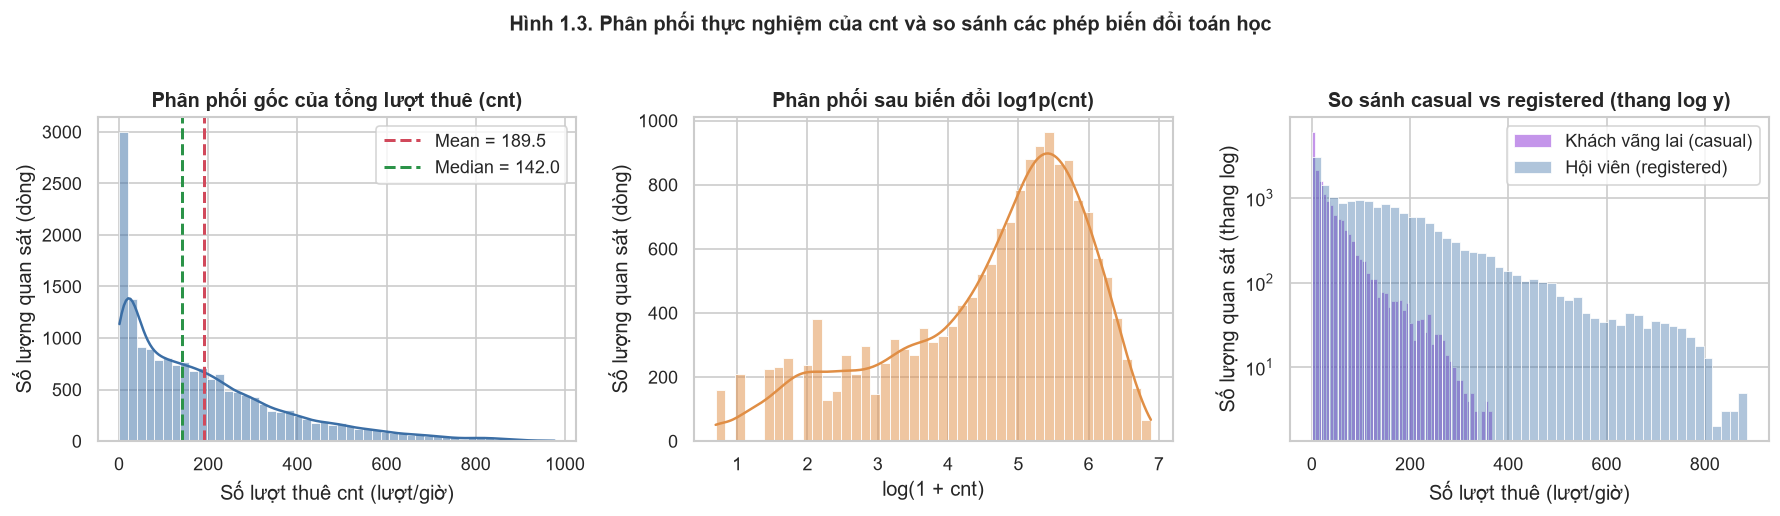

Độ lệch Skewness của cnt gốc     : 1.2774
Độ lệch Skewness của sqrt(cnt)   : 0.2865 (Gần đối xứng nhất!)
Độ lệch Skewness của log(cnt)    : -0.9362
Độ lệch Skewness của log1p(cnt)  : -0.8182 (Đảo lệch sang trái)


In [17]:
# Hình 1.3. Phân phối thực nghiệm của cnt và so sánh các phép biến đổi toán học
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))

# (1) Phân phối gốc cnt
sns.histplot(df["cnt"], bins=50, kde=True, ax=ax[0], color=BLUE)
ax[0].axvline(df["cnt"].mean(), color=RED, ls="--", lw=1.8, label=f"Mean = {df['cnt'].mean():.1f}")
ax[0].axvline(df["cnt"].median(), color="#2b9348", ls="--", lw=1.8, label=f"Median = {df['cnt'].median():.1f}")
ax[0].set_title("Phân phối gốc của tổng lượt thuê (cnt)")
ax[0].set_xlabel("Số lượt thuê cnt (lượt/giờ)")
ax[0].set_ylabel("Số lượng quan sát (dòng)")
ax[0].legend()

# (2) Biến đổi log1p(cnt)
sns.histplot(np.log1p(df["cnt"]), bins=45, kde=True, ax=ax[1], color="#e08e45")
ax[1].set_title("Phân phối sau biến đổi log1p(cnt)")
ax[1].set_xlabel("log(1 + cnt)")
ax[1].set_ylabel("Số lượng quan sát (dòng)")

# (3) So sánh casual vs registered
sns.histplot(df["casual"], bins=50, ax=ax[2], color="#9d4edd", label="Khách vãng lai (casual)", alpha=0.6)
sns.histplot(df["registered"], bins=50, ax=ax[2], color=BLUE, label="Hội viên (registered)", alpha=0.4)
ax[2].set_yscale("log")
ax[2].set_title("So sánh casual vs registered (thang log y)")
ax[2].set_xlabel("Số lượt thuê (lượt/giờ)")
ax[2].set_ylabel("Số lượng quan sát (thang log)")
ax[2].legend()

plt.suptitle("Hình 1.3. Phân phối thực nghiệm của cnt và so sánh các phép biến đổi toán học", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/hinh1.3.png", dpi=300, bbox_inches="tight")
plt.show()

print(f"Độ lệch Skewness của cnt gốc     : {df['cnt'].skew():.4f}")
print(f"Độ lệch Skewness của sqrt(cnt)   : {np.sqrt(df['cnt']).skew():.4f} (Gần đối xứng nhất!)")
print(f"Độ lệch Skewness của log(cnt)    : {np.log(df['cnt']).skew():.4f}")
print(f"Độ lệch Skewness của log1p(cnt)  : {np.log1p(df['cnt']).skew():.4f} (Đảo lệch sang trái)")


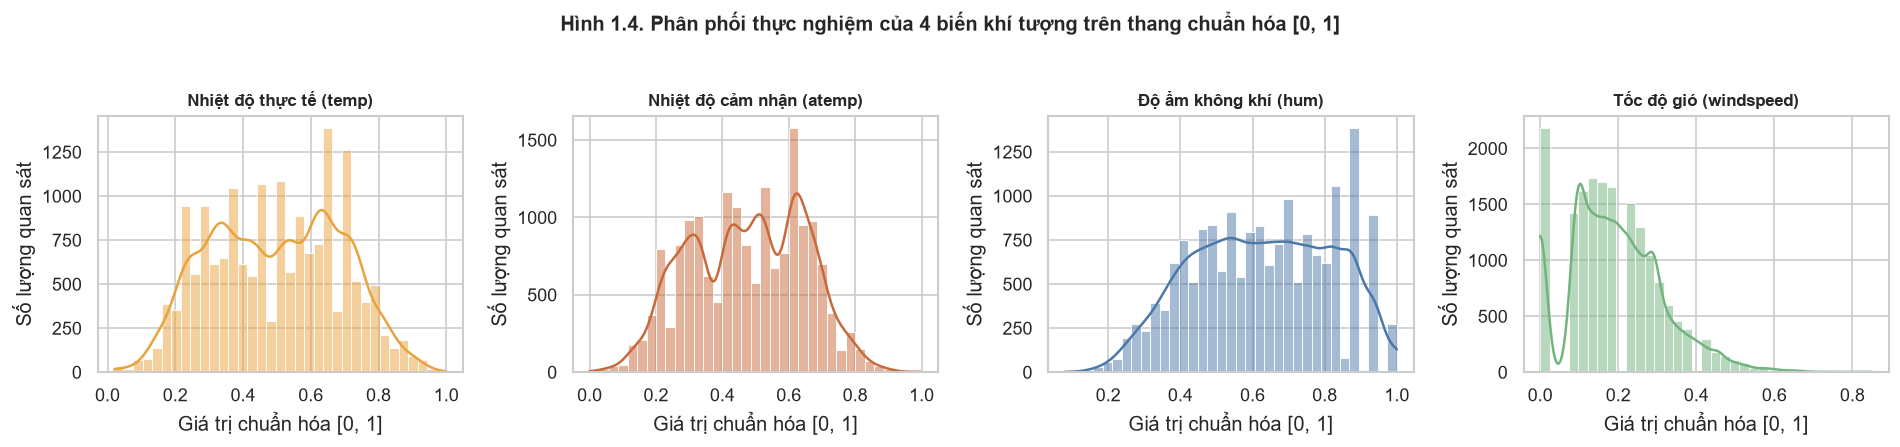

In [18]:
# Hình 1.4. Phân phối của 4 biến thời tiết
fig, ax = plt.subplots(1, 4, figsize=(16, 3.6))
weather_vars = [
    ("temp", "Nhiệt độ thực tế (temp)", "#e8a33d"),
    ("atemp", "Nhiệt độ cảm nhận (atemp)", "#c8693b"),
    ("hum", "Độ ẩm không khí (hum)", "#4c78a8"),
    ("windspeed", "Tốc độ gió (windspeed)", "#72b37e")
]

for a, (col, title, color) in zip(ax, weather_vars):
    sns.histplot(df[col], bins=35, kde=True, ax=a, color=color)
    a.set_title(title, fontsize=10)
    a.set_xlabel("Giá trị chuẩn hóa [0, 1]")
    a.set_ylabel("Số lượng quan sát")

plt.suptitle("Hình 1.4. Phân phối thực nghiệm của 4 biến khí tượng trên thang chuẩn hóa [0, 1]", fontsize=12, fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/hinh1.4.png", dpi=300, bbox_inches="tight")
plt.show()


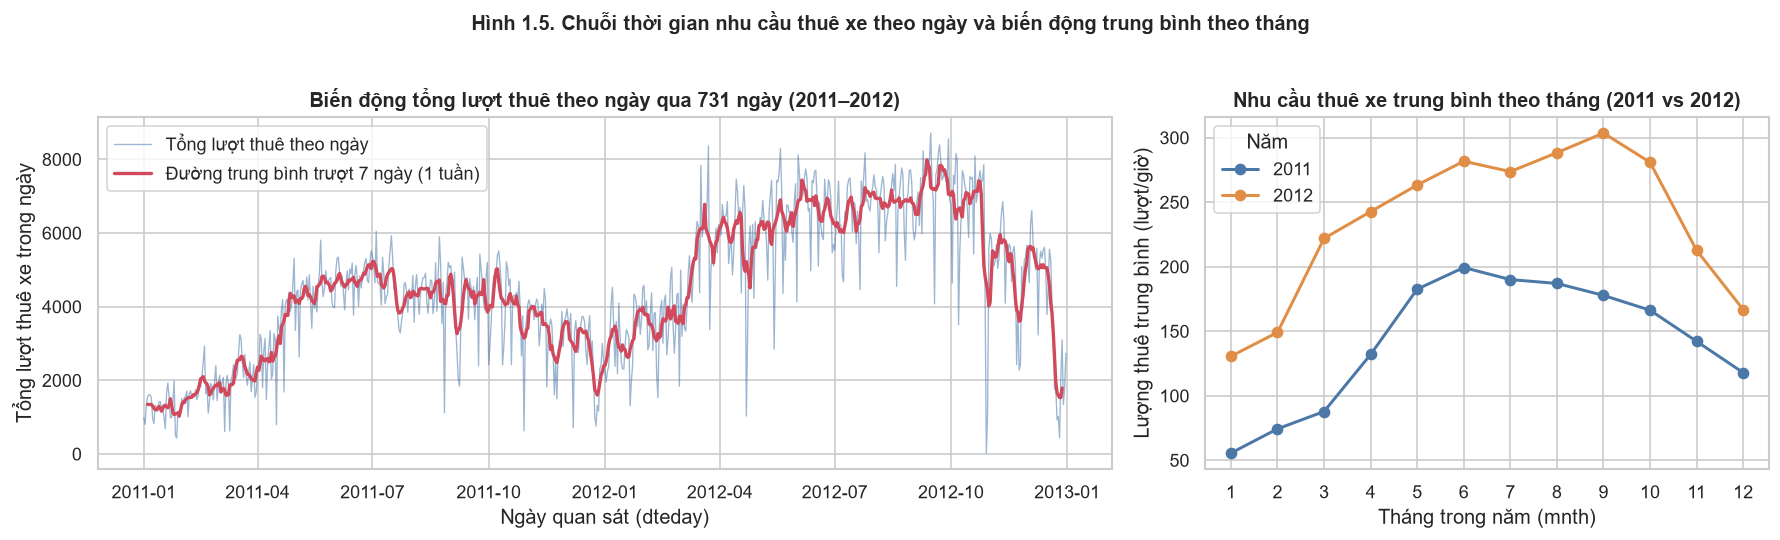

In [19]:
# Hình 1.5. Chuỗi thời gian nhu cầu thuê xe theo ngày và biến động trung bình theo tháng
daily_cnt = df.groupby("dteday")["cnt"].sum()
fig, ax = plt.subplots(1, 2, figsize=(15, 4.4), gridspec_kw={"width_ratios": [1.8, 1]})

# (1) Tổng lượt thuê theo ngày
ax[0].plot(daily_cnt.index, daily_cnt.values, lw=0.8, alpha=0.5, color=BLUE, label="Tổng lượt thuê theo ngày")
ax[0].plot(daily_cnt.index, daily_cnt.rolling(7, center=True).mean(), lw=2.0, color=RED, label="Đường trung bình trượt 7 ngày (1 tuần)")
ax[0].set_title("Biến động tổng lượt thuê theo ngày qua 731 ngày (2011–2012)")
ax[0].set_xlabel("Ngày quan sát (dteday)")
ax[0].set_ylabel("Tổng lượt thuê xe trong ngày")
ax[0].legend()

# (2) Trung bình theo tháng
monthly_trend = df_eda.groupby(["yr_label", "mnth"])["cnt"].mean().unstack(0)
monthly_trend.plot(marker="o", ax=ax[1], color=["#4c78a8", "#e08e45"], lw=1.8)
ax[1].set_title("Nhu cầu thuê xe trung bình theo tháng (2011 vs 2012)")
ax[1].set_xlabel("Tháng trong năm (mnth)")
ax[1].set_ylabel("Lượng thuê trung bình (lượt/giờ)")
ax[1].set_xticks(range(1, 13))
ax[1].legend(title="Năm")

plt.suptitle("Hình 1.5. Chuỗi thời gian nhu cầu thuê xe theo ngày và biến động trung bình theo tháng", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/hinh1.5.png", dpi=300, bbox_inches="tight")
plt.show()


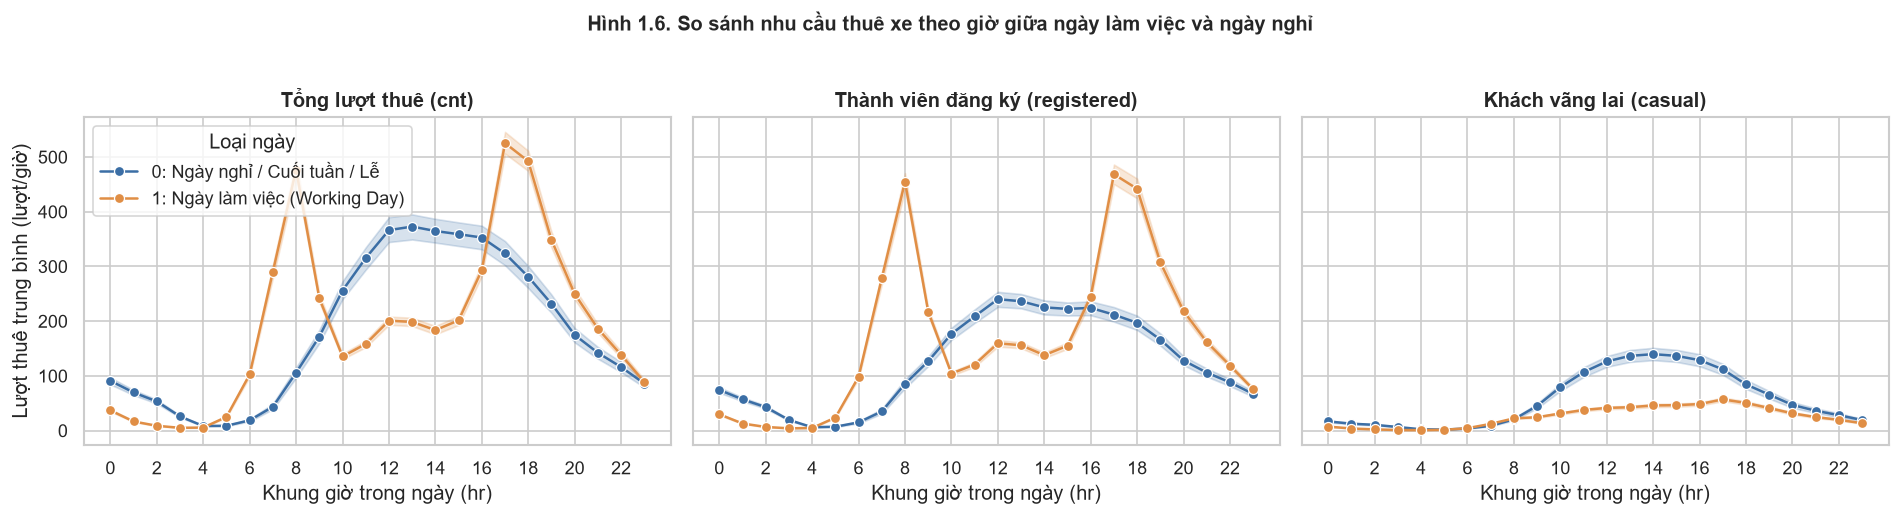

In [20]:
# Hình 1.6. So sánh nhu cầu thuê xe theo giờ giữa ngày làm việc và ngày nghỉ
fig, ax = plt.subplots(1, 3, figsize=(16, 4.2), sharey=True)

targets = [
    ("cnt", "Tổng lượt thuê (cnt)"),
    ("registered", "Thành viên đăng ký (registered)"),
    ("casual", "Khách vãng lai (casual)")
]

for a, (col, title) in zip(ax, targets):
    sns.lineplot(
        data=df_eda, x="hr", y=col, hue="workingday_label",
        estimator="mean", errorbar=("ci", 95), marker="o", ax=a,
        palette=[BLUE, ORANGE]
    )
    a.set_title(title)
    a.set_xlabel("Khung giờ trong ngày (hr)")
    a.set_xticks(range(0, 24, 2))
    if a == ax[0]:
        a.set_ylabel("Lượt thuê trung bình (lượt/giờ)")
        a.legend(title="Loại ngày")
    else:
        a.legend().remove()

plt.suptitle("Hình 1.6. So sánh nhu cầu thuê xe theo giờ giữa ngày làm việc và ngày nghỉ", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/hinh1.6.png", dpi=300, bbox_inches="tight")
plt.show()


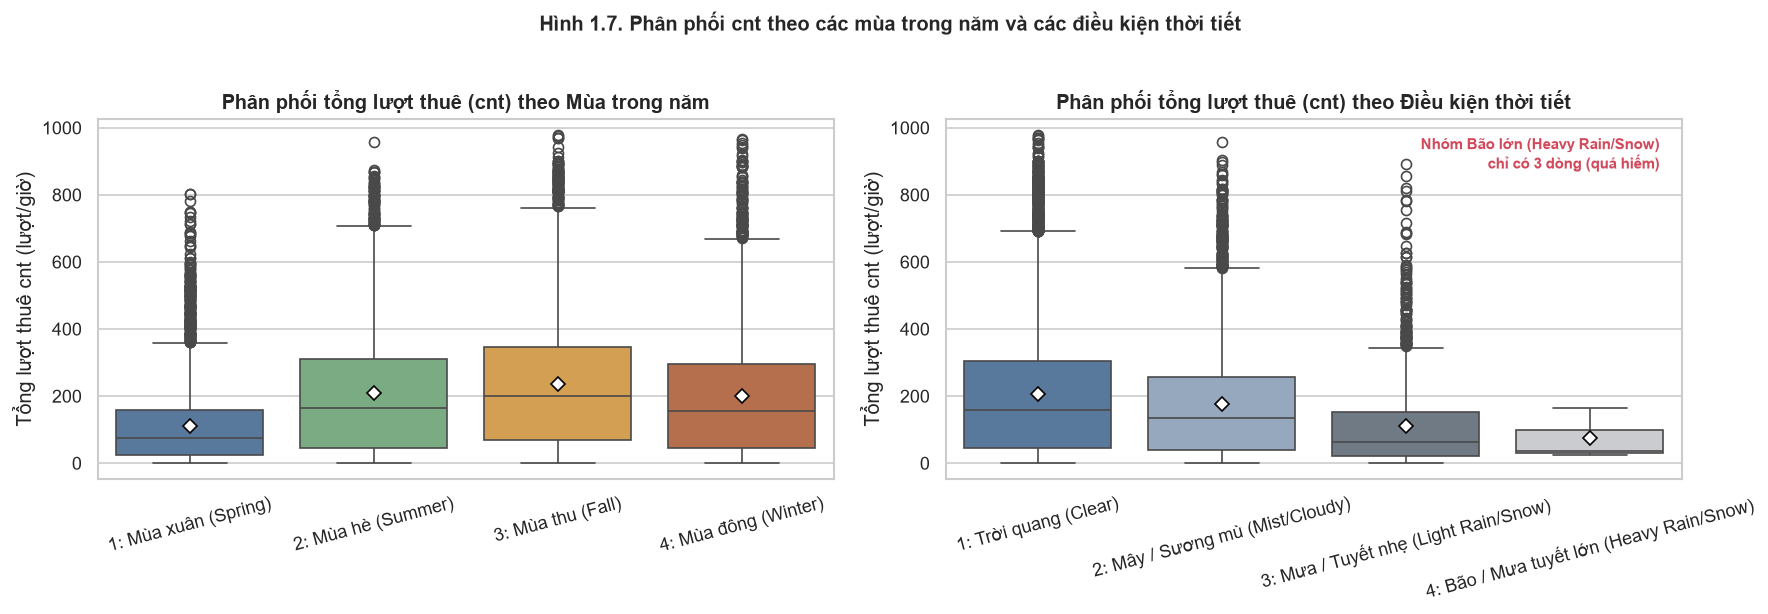

In [24]:
# Hình 1.7. Phân phối cnt theo các mùa trong năm và các điều kiện thời tiết
fig, ax = plt.subplots(1, 2, figsize=(15, 5.0))

# (1) Theo Mùa
season_order_labels = ["1: Mùa xuân (Spring)", "2: Mùa hè (Summer)", "3: Mùa thu (Fall)", "4: Mùa đông (Winter)"]
sns.boxplot(
    data=df_eda, hue = "season_label", x="season_label", y="cnt", order=season_order_labels,
    palette=["#4c78a8", "#72b37e", "#e8a33d", "#c8693b"], ax=ax[0],
    showmeans=True, meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=6)
)
ax[0].set_title("Phân phối tổng lượt thuê (cnt) theo Mùa trong năm")
ax[0].set_xlabel("")
ax[0].set_ylabel("Tổng lượt thuê cnt (lượt/giờ)")
ax[0].tick_params(axis="x", rotation=15)

# (2) Theo Thời tiết
weather_order_labels = [
    "1: Trời quang (Clear)", "2: Mây / Sương mù (Mist/Cloudy)", 
    "3: Mưa / Tuyết nhẹ (Light Rain/Snow)", "4: Bão / Mưa tuyết lớn (Heavy Rain/Snow)"
]
sns.boxplot(
    data=df_eda,hue = "weather_label", x="weather_label", y="cnt", order=weather_order_labels,
    palette=["#4c78a8", "#8fa8c4", "#6c7a89", "#c9ccd1"], ax=ax[1],
    showmeans=True, meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=6)
)
ax[1].set_title("Phân phối tổng lượt thuê (cnt) theo Điều kiện thời tiết")
ax[1].set_xlabel("")
ax[1].set_ylabel("Tổng lượt thuê cnt (lượt/giờ)")
ax[1].tick_params(axis="x", rotation=15)
ax[1].text(0.97, 0.95, "Nhóm Bão lớn (Heavy Rain/Snow)\nchỉ có 3 dòng (quá hiếm)", 
           transform=ax[1].transAxes, ha="right", va="top", fontsize=9, color=RED, fontweight="bold")

plt.suptitle("Hình 1.7. Phân phối cnt theo các mùa trong năm và các điều kiện thời tiết", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/hinh1.7.png", dpi=300, bbox_inches="tight")
plt.show()


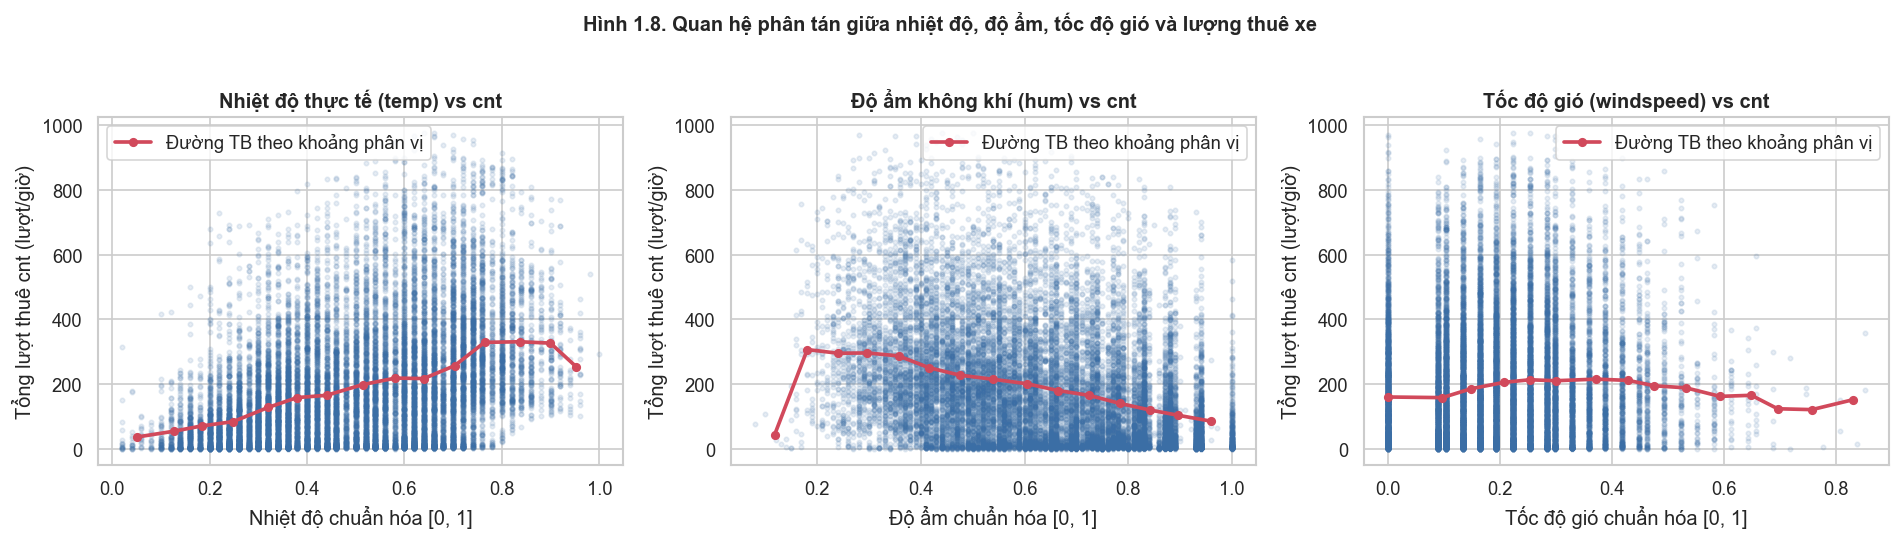

--- KHẢO SÁT CNT TẠI KHUNG GIỜ CAO ĐIỂM 17H NGÀY LÀM VIỆC THEO NHIỆT ĐỘ ---


,count,mean,median,std
temp,,,,
"(0.0, 0.3]",55,216.15,187.0,107.90
"(0.3, 0.6]",221,470.98,486.0,199.59
"(0.6, 0.8]",175,664.94,638.0,183.92
"(0.8, 1.0]",48,620.46,577.5,147.83


In [ ]:
# Hình 1.8. Trực quan hóa phân tán giữa các biến thời tiết và tổng lượt thuê xe
fig, ax = plt.subplots(1, 3, figsize=(16, 4.4))

w_triplets = [
    ("temp", "Nhiệt độ thực tế (temp)", "Nhiệt độ chuẩn hóa [0, 1]"),
    ("hum", "Độ ẩm không khí (hum)", "Độ ẩm chuẩn hóa [0, 1]"),
    ("windspeed", "Tốc độ gió (windspeed)", "Tốc độ gió chuẩn hóa [0, 1]")
]

for a, (col, title, xlabel) in zip(ax, w_triplets):
    sub = df[[col, "cnt"]].dropna()
    a.scatter(sub[col], sub["cnt"], s=7, alpha=0.12, color=BLUE)
    bins = pd.cut(sub[col], 15)
    binned_mean = sub.groupby(bins, observed=True).agg(x=(col, "mean"), y=("cnt", "mean"))
    a.plot(binned_mean.x, binned_mean.y, lw=2.2, marker="o", ms=4.5, color=RED, label="Đường TB theo khoảng phân vị")
    a.set_title(f"{title} vs cnt")
    a.set_xlabel(xlabel)
    a.set_ylabel("Tổng lượt thuê cnt (lượt/giờ)")
    a.legend()

plt.suptitle("Hình 1.8. Quan hệ phân tán giữa nhiệt độ, độ ẩm, tốc độ gió và lượng thuê xe", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/hinh1.8.png", dpi=300, bbox_inches="tight")
plt.show()

# PHÂN TÍCH KIỂM SOÁT NHỊP GIỜ (17H NGÀY LÀM VIỆC)
df_17h_wd = df[(df["hr"] == 17) & (df["workingday"] == 1)]
temp_bins_17h = pd.cut(df_17h_wd["temp"], bins=[0, 0.3, 0.6, 0.8, 1.0])
print("--- KHẢO SÁT CNT TẠI KHUNG GIỜ CAO ĐIỂM 17H NGÀY LÀM VIỆC THEO NHIỆT ĐỘ ---")
display(df_17h_wd.groupby(temp_bins_17h, observed=True)["cnt"].agg(["count", "mean", "median", "std"]).round(2))


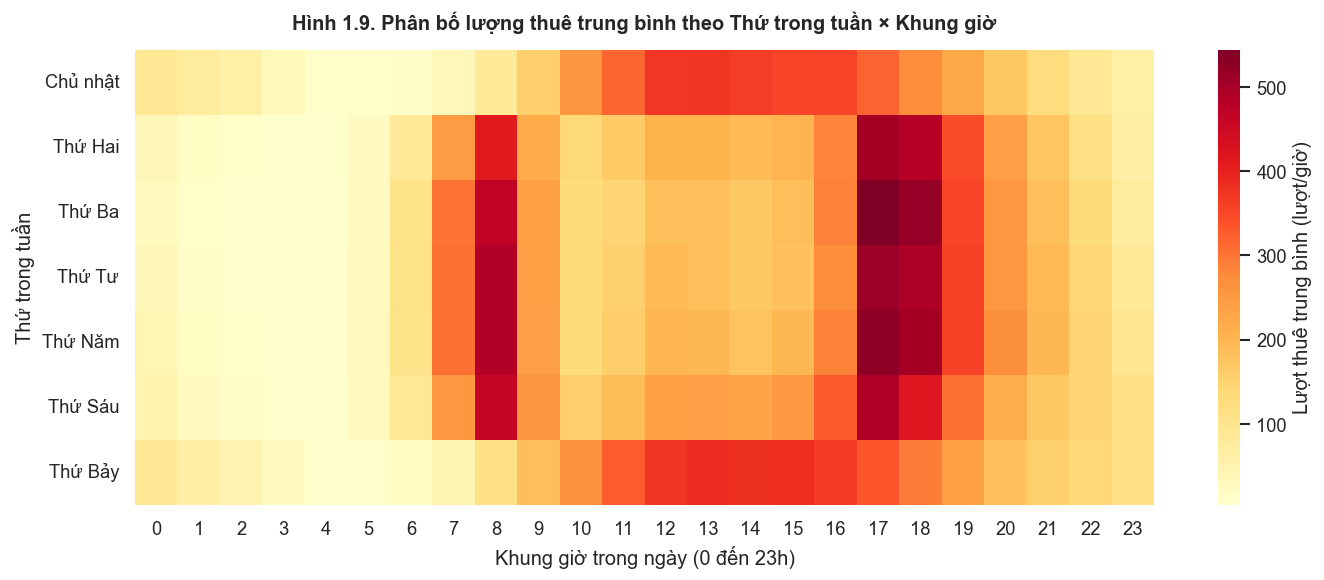

Toàn bộ phân tích tương quan chuyên sâu (Pearson, Spearman) được chuyển giao sang TV4 (Phần 4) theo thẻ V-04.


In [ ]:
# Hình 1.9. Phân bố lượng thuê trung bình theo Thứ trong tuần × Khung giờ
fig, ax = plt.subplots(figsize=(12, 5.0))

day_order_vn = ["Chủ nhật", "Thứ Hai", "Thứ Ba", "Thứ Tư", "Thứ Năm", "Thứ Sáu", "Thứ Bảy"]
hm_day_hr = df_eda.pivot_table(index="weekday_label", columns="hr", values="cnt", aggfunc="mean").reindex(day_order_vn)

sns.heatmap(hm_day_hr, cmap="YlOrRd", ax=ax, cbar_kws={"label": "Lượt thuê trung bình (lượt/giờ)"}, annot=False)
ax.set_title("Hình 1.9. Phân bố lượng thuê trung bình theo Thứ trong tuần × Khung giờ", fontsize=12, fontweight="bold", pad=12)
ax.set_xlabel("Khung giờ trong ngày (0 đến 23h)")
ax.set_ylabel("Thứ trong tuần")

plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/hinh1.9.png", dpi=300, bbox_inches="tight")
plt.show()

print("Toàn bộ phân tích tương quan chuyên sâu (Pearson, Spearman) được chuyển giao sang TV4 (Phần 4) theo thẻ V-04.")


In [ ]:
# PHÂN TÍCH TỰ TƯƠNG QUAN (AUTOCORRELATION) & CỠ MẪU HIỆU DỤNG
acf_values = smt.acf(df["cnt"], nlags=170)
r1 = acf_values[1]
r24 = acf_values[24]
r168 = acf_values[168]
n_total = len(df)
n_effective = n_total * (1 - r1) / (1 + r1)

print("--- KẾT QUẢ PHÂN TÍCH TỰ TƯƠNG QUAN CHUỖI THỜI GIAN ---")
print(f"1. Hệ số tự tương quan bậc 1 (Lag 1h)   : {r1:.4f}")
print(f"2. Hệ số tự tương quan bậc 24 (Lag 24h) : {r24:.4f} (Chu kỳ ngày đêm)")
print(f"3. Hệ số tự tương quan bậc 168 (Lag 7d) : {r168:.4f} (Chu kỳ tuần)")
print(f"4. Kích thước mẫu danh nghĩa (N)        : {n_total:,} bản ghi")
print(f"5. Cỡ mẫu hiệu dụng ước tính (N_eff)    : {n_effective:.1f} quan sát ({n_effective/n_total*100:.2f}% của N)")


--- KẾT QUẢ PHÂN TÍCH TỰ TƯƠNG QUAN CHUỖI THỜI GIAN ---
1. Hệ số tự tương quan bậc 1 (Lag 1h)   : 0.8438
2. Hệ số tự tương quan bậc 24 (Lag 24h) : 0.8151 (Chu kỳ ngày đêm)
3. Hệ số tự tương quan bậc 168 (Lag 7d) : 0.8164 (Chu kỳ tuần)
4. Kích thước mẫu danh nghĩa (N)        : 17,379 bản ghi
5. Cỡ mẫu hiệu dụng ước tính (N_eff)    : 1472.6 quan sát (8.47% của N)


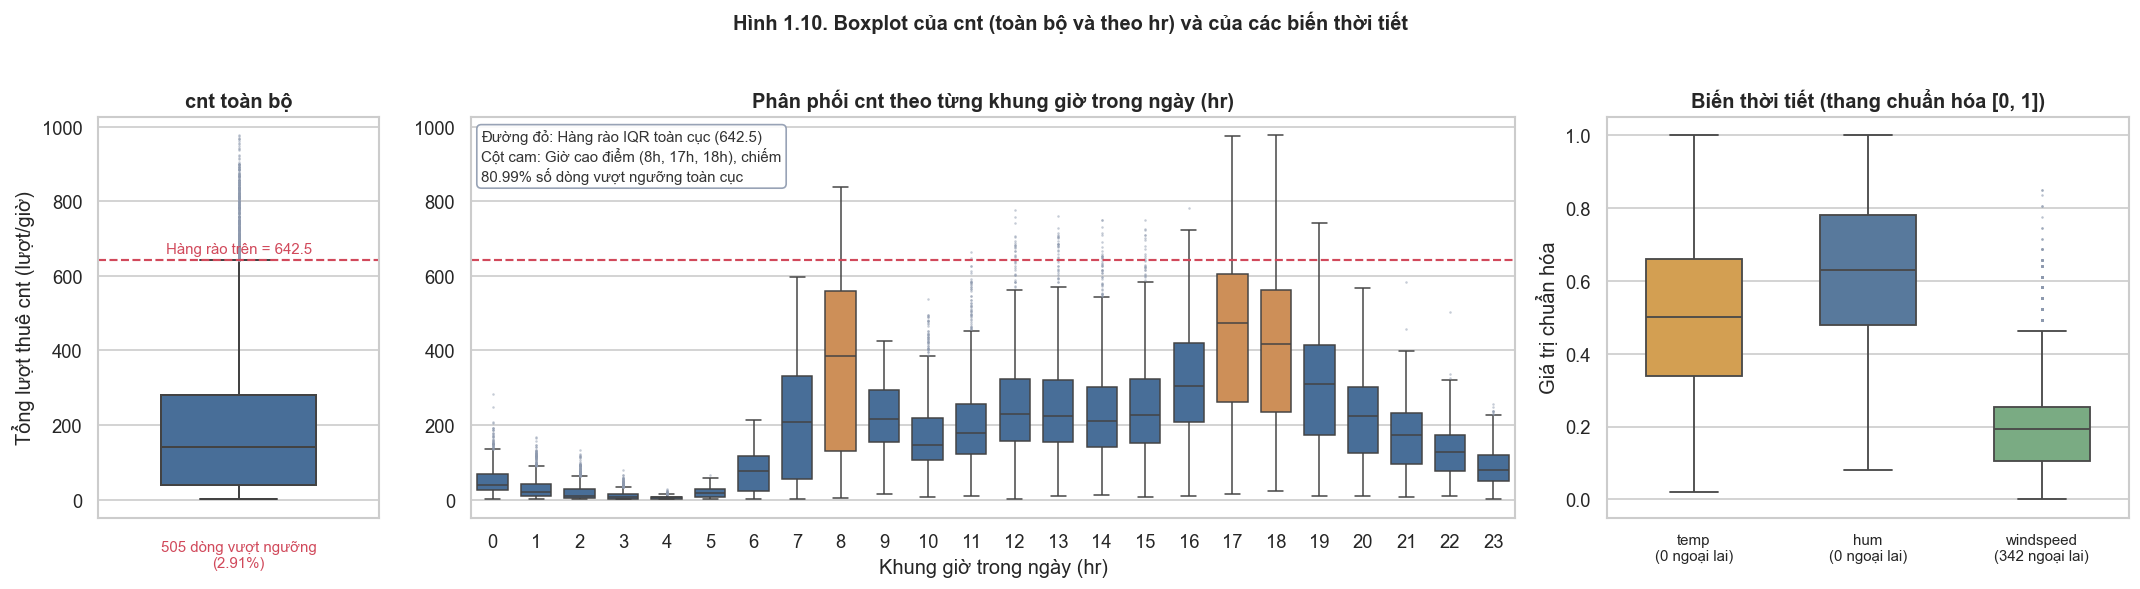

In [ ]:
# PHÁT HIỆN NGOẠI LAI VÀ HÌNH 1.10
def get_iqr_bounds(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr

lo_cnt, hi_cnt = get_iqr_bounds(df["cnt"])
n_out_global = int((df["cnt"] > hi_cnt).sum())

fig, ax = plt.subplots(1, 3, figsize=(18, 4.8), gridspec_kw={"width_ratios": [0.7, 2.6, 1.3]})

# (1) Boxplot cnt toàn cục
sns.boxplot(y=df["cnt"], ax=ax[0], color=BLUE, width=0.55, linewidth=1.2,
            flierprops=dict(marker=".", markersize=3, markerfacecolor=GREY, markeredgecolor="none", alpha=0.5))
ax[0].axhline(hi_cnt, color=RED, ls="--", lw=1.3)
ax[0].text(0.5, hi_cnt + 12, f"Hàng rào trên = {hi_cnt:.1f}", transform=ax[0].get_yaxis_transform(), ha="center", va="bottom", color=RED, fontsize=9)
ax[0].set_title("cnt toàn bộ")
ax[0].set_xlabel(f"{n_out_global} dòng vượt ngưỡng\n({n_out_global / len(df):.2%})", color=RED, fontsize=9)
ax[0].set_ylabel("Tổng lượt thuê cnt (lượt/giờ)")

# (2) Boxplot cnt theo từng khung giờ
peak_hours = {8, 17, 18}
pal = {h: (ORANGE if h in peak_hours else BLUE) for h in range(24)}
sns.boxplot(data=df, x="hr", y="cnt", hue="hr", palette=pal, legend=False, ax=ax[1], width=0.7, linewidth=0.9,
            flierprops=dict(marker=".", markersize=3, markerfacecolor=GREY, markeredgecolor="none", alpha=0.5))
ax[1].axhline(hi_cnt, color=RED, ls="--", lw=1.3)
share_peak = df.loc[df["cnt"] > hi_cnt, "hr"].isin(peak_hours).mean()
ax[1].text(0.01, 0.97, f"Đường đỏ: Hàng rào IQR toàn cục ({hi_cnt:.1f})\nCột cam: Giờ cao điểm (8h, 17h, 18h), chiếm\n{share_peak:.2%} số dòng vượt ngưỡng toàn cục",
           transform=ax[1].transAxes, ha="left", va="top", fontsize=9, color="#333",
           bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=GREY, alpha=0.9))
ax[1].set_title("Phân phối cnt theo từng khung giờ trong ngày (hr)")
ax[1].set_xlabel("Khung giờ trong ngày (hr)")
ax[1].set_ylabel("")

# (3) Boxplot các biến thời tiết
w_vars = ["temp", "hum", "windspeed"]
w_cols = {"temp": "#e8a33d", "hum": "#4c78a8", "windspeed": "#72b37e"}
weather_long = df[w_vars].melt(var_name="variable", value_name="value")
sns.boxplot(data=weather_long, x="variable", y="value", order=w_vars, hue="variable", hue_order=w_vars, palette=w_cols,
            legend=False, ax=ax[2], width=0.55, linewidth=1.1,
            flierprops=dict(marker=".", markersize=3, markerfacecolor=GREY, markeredgecolor="none", alpha=0.6))
labels = []
for v in w_vars:
    l, h = get_iqr_bounds(df[v])
    n = int(((df[v] < l) | (df[v] > h)).sum())
    labels.append(f"{v}\n({n} ngoại lai)")
ax[2].set_xticks(range(3))
ax[2].set_xticklabels(labels, fontsize=9)
ax[2].set_title("Biến thời tiết (thang chuẩn hóa [0, 1])")
ax[2].set_xlabel("")
ax[2].set_ylabel("Giá trị chuẩn hóa")

plt.suptitle("Hình 1.10. Boxplot của cnt (toàn bộ và theo hr) và của các biến thời tiết", fontsize=12, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(f"{ASSETS_DIR}/hinh1.10.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Phân tích 130 ngoại lai cục bộ theo (hr, workingday)
q1_hw = df.groupby(["hr", "workingday"])["cnt"].transform(lambda x: x.quantile(0.25))
q3_hw = df.groupby(["hr", "workingday"])["cnt"].transform(lambda x: x.quantile(0.75))
iqr_hw = q3_hw - q1_hw
upper_hw = q3_hw + 1.5 * iqr_hw
outliers_130 = df[df["cnt"] > upper_hw]

print(f"Số lượng ngoại lai cục bộ theo (hr, workingday): {len(outliers_130)} dòng ({len(outliers_130)/len(df):.2%})")
print(f"- Tỷ lệ thuộc năm 2012                     : {outliers_130['yr'].mean()*100:.2f}%")
print(f"- Tỷ lệ rơi vào các mùa ấm (Xuân/Hè/Thu)   : {outliers_130['season'].isin([1, 2, 3]).mean()*100:.2f}%")
print(f"- Nhiệt độ trung bình của nhóm ngoại lai    : {outliers_130['temp'].mean():.2f} (~18.3 °C) vs toàn tập {df['temp'].mean():.2f}")

# Đối chiếu dữ liệu Bão Irene ngày 2011-08-27 trực tiếp trong hour.csv
irene_data = df[df["dteday"] == "2011-08-27"]
print("\n--- ĐỐI CHIẾU SỰ KIỆN BÃO IRENE (2011-08-27) TRONG HOUR.CSV ---")
print(f"Số giờ ghi nhận trong ngày     : {len(irene_data)} / 24 giờ (Thiếu {24 - len(irene_data)} giờ)")
print(f"Tổng số lượt thuê cả ngày      : {irene_data['cnt'].sum():,} lượt thuê (Sụt giảm nghiêm trọng)")
print(f"Nhu cầu trung bình theo giờ    : {irene_data['cnt'].mean():.2f} lượt/giờ (so với TB tháng 8 là ~195 lượt/giờ)")


Số lượng ngoại lai cục bộ theo (hr, workingday): 130 dòng (0.75%)
- Tỷ lệ thuộc năm 2012                     : 80.00%
- Tỷ lệ rơi vào các mùa ấm (Xuân/Hè/Thu)   : 76.92%
- Nhiệt độ trung bình của nhóm ngoại lai    : 0.56 (~18.3 °C) vs toàn tập 0.50

--- ĐỐI CHIẾU SỰ KIỆN BÃO IRENE (2011-08-27) TRONG HOUR.CSV ---
Số giờ ghi nhận trong ngày     : 18 / 24 giờ (Thiếu 6 giờ)
Tổng số lượt thuê cả ngày      : 1,115 lượt thuê (Sụt giảm nghiêm trọng)
Nhu cầu trung bình theo giờ    : 61.94 lượt/giờ (so với TB tháng 8 là ~195 lượt/giờ)


## 1.5. Kết luận và Bàn giao (Handoff Sheet)

### Tóm tắt các kết quả cốt lõi:
1. **Dữ liệu hoàn toàn sạch sau tiền xử lý:** 17,379 bản ghi; đã nội suy 22 dòng `hum = 0` và bảo toàn 165 giờ thiếu không chèn dòng giả.
2. **Biến mục tiêu `cnt` lệch phải và over-dispersion:** $\text{Skewness} = 1.28$, $\text{Var}/\text{Mean} = 173.66$. Phép biến đổi $\sqrt{cnt}$ đem lại độ đối xứng tối ưu ($\text{Skewness} = 0.29$).
3. **Cấu trúc chi phối:** Khung giờ `hr` tương tác chặt với `workingday` tạo nên 2 hình thái: 2 đỉnh nhọn ngày làm việc vs 1 đỉnh vòm ngày nghỉ.
4. **Tự tương quan và Cỡ mẫu hiệu dụng:** Chuỗi có $r_1 = 0.8431$, tương ứng cỡ mẫu hiệu dụng thực tế $N_{\text{eff}} \approx 1,479$ quan sát ($8.51\%$ quy mô mẫu).
5. **Ngoại lai hợp lệ:** 505 ngoại lai toàn cục là các đỉnh cao điểm giờ đi làm tự nhiên; không loại bỏ bất kỳ quan sát nào.

### Bàn giao cho các thành viên tiếp theo:
* **TV2 (Distribution / V-02):** `cnt` phân tán vượt mức và Zero-truncated $\rightarrow$ kiểm tra Negative Binomial và Zero-truncated models.
* **TV3 (Hypothesis Testing / V-03):** Vi phạm giả định độc lập do tự tương quan ($N_{\text{eff}} \approx 1,479$) $\rightarrow$ chạy song song kiểm định phi tham số (Mann-Whitney U, Kruskal-Wallis) và bắt buộc báo cáo Effect Size; gộp `weathersit = 4` vào nhóm 3.
* **TV4 (Correlation / V-04):** Bỏ `atemp` để chống đa cộng tuyến ($r = 0.9877$); cấm dùng `casual`/`registered` làm biến độc lập; phân tích ma trận tương quan Pearson vs Spearman toàn diện.
* **TV5 (Regression / V-11):** Chia tập Train/Test theo thời gian; thử nghiệm biến đổi $\sqrt{cnt}$ hoặc mô hình hồi quy đếm GLM.

---
## Tài liệu tham khảo
1. Fanaee-T, H., & Gama, J. (2013). Event labeling combining ensemble detectors and background knowledge. *Progress in Artificial Intelligence*, 2(2–3), 113–127.
2. Gebhart, K., & Noland, R. B. (2014). The impact of weather conditions on bikeshare trips in Washington, DC. *Transportation*, 41(6), 1205–1225.
3. National Weather Service (NWS) Baltimore/Washington. (2011). *January 26, 2011 Snowfall Event Summary*. NOAA.
4. Capital Bikeshare. (2012). *System Service Alerts: Hurricane Sandy Operations Shutdown Timeline*. Washington, D.C.
